# The Kelly criterion for position sizing

**pyportfolios.com research** · SPY, Jan 2000 – Dec 2024 · NumPy · Pandas · Matplotlib · yfinance

The growth-optimal bet size on real data. We

1. estimate the continuous Kelly fraction **f\* = μ/σ²** from 25 years of SPY,
2. trace the realised growth-vs-fraction curve g(f) and find its peak,
3. rebalance daily to full / half / quarter Kelly through the dot-com bust,
   the GFC and COVID, and
4. bootstrap 2,000 ten-year futures (seed 42) to see the drawdown
   price of each sizing.

The punchline is the flatness of the peak: half-Kelly gives up little growth
for far less pain.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

plt.rcParams["figure.figsize"] = (10, 5)
SEED = 42

## 1 · Data: 25 years of SPY

A quarter century that includes two ~50% bear markets and a pandemic crash —
exactly the tails Kelly sizing has to survive.

In [2]:
px = yf.download("SPY", start="2000-01-01", end="2025-01-01",
                 auto_adjust=True, progress=False)["Close"].squeeze().dropna()
ret = px.pct_change().dropna()
print(f"{len(ret)} daily returns, {len(ret)/252:.1f} years")

6288 daily returns, 25.0 years


## 2 · The Kelly fraction from μ and σ

For continuous returns the growth-optimal leverage is f* = μ/σ² (excess
returns; we take cash ≈ 0 for clarity — subtracting a realistic T-bill rate
lowers f* further, it never raises it).

In [3]:
mu_a    = ret.mean() * 252
sigma_a = ret.std(ddof=1) * np.sqrt(252)
f_star  = ret.mean() / ret.var(ddof=1)

print(f"mu     = {mu_a: .4f} / yr")
print(f"sigma  = {sigma_a: .4f} / yr")
print(f"f*     = {f_star: .2f}x leverage")

mu     =  0.0927 / yr
sigma  =  0.1939 / yr
f*     =  2.47x leverage


## 3 · The growth curve g(f), realised

Instead of the quadratic approximation f·μ − f²σ²/2 we compute the *exact*
realised growth rate g(f) = 252 · E[ln(1 + f·r)] on the actual daily returns —
fat tails included. The curve rises to a single peak at f* and then rolls over
into negative territory: past the peak, more risk buys *less* growth.

    full Kelly f=2.47: g = 0.1137/yr
    half Kelly f=1.23: g = 0.0857/yr
 quarter Kelly f=0.62: g = 0.0500/yr


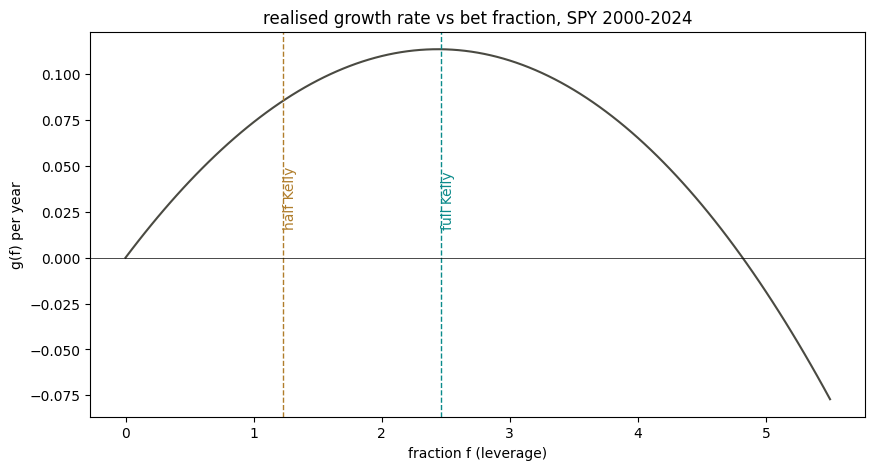

In [4]:
fgrid = np.linspace(0, 5.5, 111)
g = np.array([252 * np.mean(np.log1p(f * ret.values)) for f in fgrid])

plt.plot(fgrid, g, color="#4a4a42")
for f, label, c in [(f_star, "full", "#0a8a8a"), (f_star/2, "half", "#b07d2b")]:
    plt.axvline(f, ls="--", lw=1, color=c)
    plt.annotate(f"{label} Kelly", (f, g.max()*0.15), color=c, rotation=90)
plt.axhline(0, color="k", lw=0.5)
plt.title("realised growth rate vs bet fraction, SPY 2000-2024")
plt.xlabel("fraction f (leverage)"); plt.ylabel("g(f) per year");

for f, label in [(f_star, "full"), (f_star/2, "half"), (f_star/4, "quarter")]:
    gf = 252 * np.mean(np.log1p(f * ret.values))
    print(f"{label:>8} Kelly f={f:4.2f}: g = {gf:6.4f}/yr")
plt.show()

## 4 · Full vs half vs quarter Kelly through 25 real years

Rebalance daily to a constant fraction and let history do its worst. Wealth is
plotted on a log scale — with leverage above 2× the drawdowns are the story,
not the terminal wealth.

    full (f=2.47): terminal   17.06x  CAGR 12.04%  maxDD -91.2%


    half (f=1.23): terminal    8.49x  CAGR  8.95%  maxDD -63.9%
 quarter (f=0.62): terminal    3.48x  CAGR  5.13%  maxDD -37.5%
  SPY 1x (f=1.00): terminal    6.32x  CAGR  7.67%  maxDD -55.2%


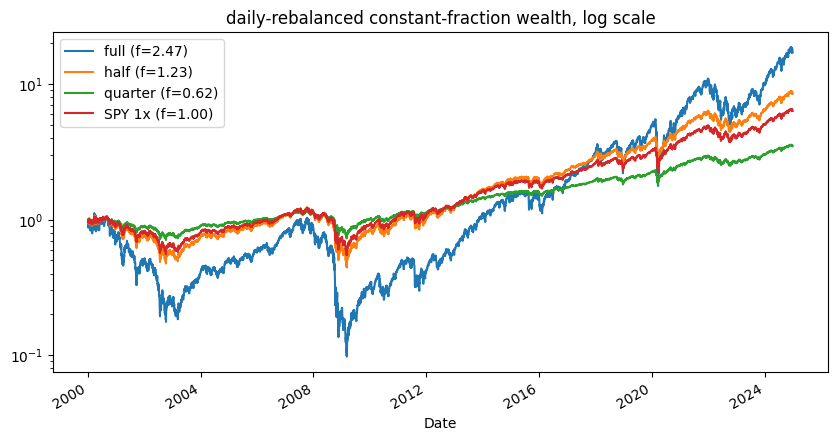

In [5]:
fracs = {"full": f_star, "half": f_star/2, "quarter": f_star/4, "SPY 1x": 1.0}
for label, f in fracs.items():
    eq = pd.Series(np.cumprod(1 + f * ret.values), index=ret.index)
    dd = (eq / eq.cummax() - 1).min()
    cagr = eq.iloc[-1] ** (252 / len(eq)) - 1
    print(f"{label:>8} (f={f:4.2f}): terminal {eq.iloc[-1]:7.2f}x  "
          f"CAGR {cagr:6.2%}  maxDD {dd:6.1%}")
    eq.plot(logy=True, label=f"{label} (f={f:.2f})")
plt.legend(); plt.title("daily-rebalanced constant-fraction wealth, log scale");

## 5 · The drawdown price, bootstrapped

Resample 10-year futures from the same return distribution (seeded) and read
the drawdown distribution per sizing. This is the table that talks people out
of full Kelly.

In [6]:
rng = np.random.default_rng(SEED)
sims = ret.values[rng.integers(0, len(ret), size=(2000, 2520))]

def max_dd(w):
    peak = np.maximum.accumulate(w, axis=1)
    return (w / peak - 1).min(axis=1)

print(f"{'sizing':>8} {'median 10y':>12} {'5th pct':>9} {'median maxDD':>13}")
for label, f in [("full", f_star), ("half", f_star/2), ("quarter", f_star/4)]:
    w = np.cumprod(1 + f * sims, axis=1)
    print(f"{label:>8} {np.median(w[:, -1]):11.2f}x {np.percentile(w[:, -1], 5):8.2f}x "
          f"{np.median(max_dd(w)):12.1%}")

  sizing   median 10y   5th pct  median maxDD
    full        3.00x     0.24x       -73.9%
    half        2.31x     0.65x       -45.3%


 quarter        1.63x     0.87x       -25.0%


## Takeaways

- On real SPY data f* ≈ 2× — and nobody should run it: μ is the least reliable
  estimate in finance, and the curve punishes overshooting far more than
  undershooting.
- The peak is flat: half-Kelly keeps most of the growth rate for roughly half
  the volatility and a far shallower worst drawdown.
- Full Kelly turned the GFC into a near-wipeout drawdown; half Kelly hurt but
  survived comfortably. That asymmetry is the whole argument.

*© pyportfolios.com — runnable companion to the article. Data: Yahoo Finance via yfinance.*